In [38]:
import json
import os
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import spearmanr, rankdata
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from sklearn.feature_selection import VarianceThreshold
from tqdm.notebook import tqdm
from dateutil.relativedelta import relativedelta


import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

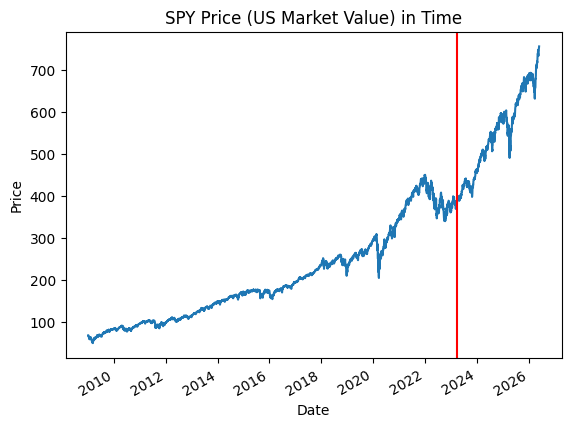

In [39]:
hist = yf.Ticker('SPY').history(start='2009-01-01')
hist['Close'].plot()

plt.title('SPY Price (US Market Value) in Time')
plt.ylabel('Price')
plt.axvline(x = '2023-03-31', color='red')
plt.show()

In [40]:
def generate_parquets_from_csv(data_dir: str = 'data_quarterly', max_missing_pct: float = 0.2):
    sectors = [f for f in os.listdir(data_dir) if not f.endswith('.json')]
    for sector in tqdm(sectors):
        df = export_csv_for_training(data_dir, [sector], get_metadata=True)

        output_dir = Path(data_dir + '_parquet')
        output_dir.mkdir(parents=True, exist_ok=True)
        df = normalize_schema(df)

        metadata_cols = ['ticker', 'sector', 'industry', 'fiscalDateEnding', 'filing_date_used']
        feature_cols = [c for c in df.columns if c not in metadata_cols]
        mask = df[feature_cols].isnull().mean(axis=1) <= max_missing_pct
        print(f'{sector}: dropping {(~mask).sum()}/{len(df)} rows with >{max_missing_pct:.0%} missing data')
        df = df[mask]

        df.to_parquet(output_dir / f'{sector}.parquet', index=False)
        print(f'Generated data for {sector}')

def normalize_schema(df: pd.DataFrame) -> pd.DataFrame:
    # force datetime columns
    date_cols = ['fiscalDateEnding', 'filing_date_used']
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    # force numeric columns
    for col in df.columns:
        if col not in date_cols:
            try:
                df[col] = pd.to_numeric(df[col])
            except:
                pass

    # force metadata columns
    for col in ['ticker', 'sector', 'industry']:
        if col in df.columns:
            df[col] = df[col].astype('string')

    return df

def export_csv_for_training(
        data_dir: str = 'data_quarterly', 
        sectors: list | None = None,
        get_metadata: bool = False,
    ) -> pd.DataFrame:
    start = time.time()

    if get_metadata:
        with open(os.path.join(data_dir, 'metadata.json')) as f:
            metadata = json.load(f)

    if sectors is None:
        sectors = [f for f in os.listdir(data_dir) if not f.endswith('.json')]

    frames = []

    for sector in sectors:
        sector_path = os.path.join(data_dir, sector)

        for file in os.listdir(sector_path):
            if file.endswith('.csv'):
                df = pd.read_csv(os.path.join(sector_path, file))

            if get_metadata:
                ticker = file[:file.find('.')]
                meta = metadata[ticker]
                meta['ticker'] = ticker

                df_metadata = pd.DataFrame([meta] * len(df), index=df.index)
                df = pd.concat([df, df_metadata], axis=1)
                
            frames.append(df)

    if frames:
        dataset = pd.concat(frames, ignore_index=True)
        dataset['fiscalDateEnding'] = pd.to_datetime(dataset['fiscalDateEnding'])
        print(f"Dataset load time: {(time.time() - start):.2f}s")
        return dataset
    else:
        print("Warnign: No frames found, returning empty DF")
        return pd.DataFrame()

def export_parquets_for_training(
        data_dir: str = 'data_quarterly_parquet',
        sectors: list | None = None,
        get_metadata: bool = False,
        cross_sectional_rank: bool = False,
    ) -> pd.DataFrame:
    start = time.time()

    if sectors is None:
        sectors = [f for f in os.listdir(data_dir)]
    else:
        sectors = [f'{name}.parquet' for name in sectors]

    files = [Path(data_dir) / sector for sector in sectors]
    dataset = pd.read_parquet(files)

    # if not get_metadata:
    #     dataset = dataset.drop(columns=['sector', 'industry', 'ticker'], errors='ignore')

    dataset = pd.read_parquet(files)
    dataset['fiscalDateEnding'] = pd.to_datetime(dataset['fiscalDateEnding'])
    dataset = dataset.sort_values("fiscalDateEnding").reset_index(drop=True)

    # ── Cross-sectional ranking ───────────────────────────────────────────────
    # Must happen HERE — after load, before dropping sector/metadata columns
    # because the ranking needs sector and fiscalDateEnding as group keys.
    # It is safe against lookahead: each date's ranks use only
    # companies reporting on that date, no future data involved.
    if cross_sectional_rank:
        if 'sector' not in dataset.columns:
            print("Warning: 'sector' column not found — "
                  "cannot rank within sector, skipping cross-sectional ranking. "
                  "Load with get_metadata=True in generate_parquets_from_csv.")
        else:
            dataset = add_cross_sectional_ranks(dataset)

    if not get_metadata:
        dataset = dataset.drop(
            columns=['sector', 'industry', 'ticker'], errors='ignore'
        )

    print(f"Dataset load time: {(time.time() - start):.2f}s")
    return dataset
    
    # dataset['fiscalDateEnding'] = pd.to_datetime(dataset['fiscalDateEnding'])
    # dataset = dataset.sort_values("fiscalDateEnding").reset_index(drop=True)
    # print(f"Dataset load time: {(time.time() - start):.2f}s")
    # return dataset

def find_split_date(df: pd.DataFrame, desired_ratio: float = 0.8):
    return df['fiscalDateEnding'].quantile(desired_ratio)

# def split_target(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
#     df_X = df.drop(columns=['target', 'filing_date_used'], errors='ignore')
#     df_y = df['target']
#     return df_X, df_y

def split_target_with_date_index(df: pd.DataFrame):
    """Like split_target but keeps fiscalDateEnding as index for CV inspection."""
    X = df.drop(columns=["target", "filing_date_used"], errors="ignore")
    X = X.set_index("fiscalDateEnding")
    y = df["target"]
    y.index = X.index
    return X, y

def cleanup_base(X_train, X_test):
    """Always apply — safe for all models"""
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test  = X_test.replace([np.inf, -np.inf], np.nan)

    lower = X_train.quantile(0.01)
    upper = X_train.quantile(0.99)
    X_train = X_train.clip(lower=lower, upper=upper, axis=1)
    X_test  = X_test.clip(lower=lower, upper=upper, axis=1)

    medians = X_train.median()
    X_train = X_train.fillna(medians)
    X_test  = X_test.fillna(medians)

    selector = VarianceThreshold(threshold=1e-5)
    mask = selector.fit(X_train).get_support()
    cols = X_train.columns[mask]
    return X_train[cols], X_test[cols]

def cleanup_linear(X_train, X_test):
    """Apply after cleanup_base for linear models"""
    corr = X_train.corr().abs()
    upper_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper_corr.columns if any(upper_corr[col] > 0.95)]
    X_train = X_train.drop(columns=to_drop)
    X_test  = X_test.drop(columns=to_drop)

    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), 
                           columns=X_train.columns, index=X_train.index)
    X_test  = pd.DataFrame(scaler.transform(X_test),
                           columns=X_test.columns, index=X_test.index)
    
    return X_train, X_test


def add_cross_sectional_ranks(df: pd.DataFrame, 
                               group_cols: list = ['fiscalDateEnding', 'sector'],
                               min_group_size: int = 5) -> pd.DataFrame:
    """
    Replace each feature value with its percentile rank within
    the sector x date group. Falls back to date-only ranking
    for groups smaller than min_group_size.
    
    Must be called while sector and fiscalDateEnding are still columns
    (before they are dropped or set as index).
    """
    metadata_cols = ['ticker', 'sector', 'industry', 'fiscalDateEnding', 
                     'filing_date_used', 'target']
    feature_cols  = [c for c in df.columns if c not in metadata_cols]

    print(f"Cross-sectional ranking {len(feature_cols)} features "
          f"across {df['fiscalDateEnding'].nunique()} dates "
          f"x {df['sector'].nunique()} sectors...")

    ranked = df.copy()

    # Precompute group sizes once — reused for every feature
    group_sizes   = df.groupby(group_cols)['sector'].transform('size')
    large_enough  = group_sizes >= min_group_size

    # Warn about thin groups so you know how often fallback fires
    thin_groups = (
        df.groupby(group_cols).size()
        .reset_index(name='n')
        .query('n < @min_group_size')
    )
    if len(thin_groups) > 0:
        print(f"  Warning: {len(thin_groups)} sector×date groups have "
              f"< {min_group_size} stocks — using date-only rank as fallback")
        print(f"  Smallest groups:\n{thin_groups.nsmallest(5, 'n').to_string(index=False)}")

    for col in tqdm(feature_cols, desc="  Ranking features", leave=False):
        sector_date_rank = df.groupby(group_cols)[col].rank(
            pct=True, na_option='keep'
        )
        date_only_rank = df.groupby('fiscalDateEnding')[col].rank(
            pct=True, na_option='keep'
        )
        ranked[col] = np.where(large_enough, sector_date_rank, date_only_rank)

    return ranked

def rank_target_globally(y: pd.Series) -> pd.Series:
    """
    Global percentile rank across the entire training window.
    Use for feature selection and model training — NOT per-date,
    which would erase persistent alpha signal.
    """
    return pd.Series(rankdata(y) / len(y), index=y.index, name=y.name)

   
# def split_dataset(
#         df: pd.DataFrame,
#         desired_ratio: float = 0.8,
#         cleanup: bool = False,
#         is_linear: bool = False
#     ):
#     split_date = find_split_date(df, desired_ratio)
#     print(f"Derived split date: {split_date.strftime("%Y-%m-%d")}")
    
#     train = df[df['fiscalDateEnding'] <= split_date].copy()
#     test = df[df['fiscalDateEnding'] > split_date].copy()

#     X_train, y_train = split_target_with_date_index(train)
#     X_test, y_test = split_target_with_date_index(test)

#     if cleanup:
#         X_train, X_test = cleanup_base(X_train, X_test)
#         if is_linear:
#             X_train, X_test = cleanup_linear(X_train, X_test)

#     return X_train, X_test, y_train, y_test

In [41]:
# ─── Config additions ─────────────────────────────────────────────────────────
USE_GPU        = True   # set False to fall back to CPU
DEVICE         = "cuda" if USE_GPU else "cpu"

# ─── GPU check ────────────────────────────────────────────────────────────────
def check_gpu():
    try:
        import subprocess
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
            capture_output=True, text=True, timeout=5
        )
        if result.returncode == 0:
            print(f"GPU detected: {result.stdout.strip()}")
            return True
    except Exception:
        pass
    print("No GPU detected — falling back to CPU")
    return False

if USE_GPU:
    USE_GPU = check_gpu()
    DEVICE  = "cuda" if USE_GPU else "cpu"

GPU detected: NVIDIA GeForce GTX 1070, 8192 MiB


In [42]:
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# import optuna
# import shap
# import json
# from pathlib import Path

# from tqdm import tqdm
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.feature_selection import RFE, VarianceThreshold
# from sklearn.inspection import permutation_importance
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import (
#     root_mean_squared_error, mean_squared_error, r2_score,
#     roc_auc_score, accuracy_score,
#     matthews_corrcoef, log_loss,
# )
# from sklearn.base import clone
# from scipy.stats import spearmanr
# from concurrent.futures import ThreadPoolExecutor

# optuna.logging.set_verbosity(optuna.logging.WARNING)

# # ─── Config ───────────────────────────────────────────────────────────────────
N_TRIALS_SHORT = 30
N_TRIALS_FULL  = 150
TOP_K          = 100
N_FOLDS        = 5       # for TimeSeriesSplit
TRAIN_RATIO    = 0.7     # 70% train | 15% val | 15% test (approximate)
VAL_RATIO      = 0.85
RANDOM_STATE   = 42
ALPHA_WEIGHT   = 0.5
BETA_WEIGHT    = 0.5
# STUDY_STORAGE = "sqlite:///optuna_studies.db"

# # # ─── 1. Load & split ──────────────────────────────────────────────────────────

# df = export_parquets_for_training()

# # Time-based three-way split
# # find_split_date works on the full df's date distribution
# train_cutoff = find_split_date(df, TRAIN_RATIO)
# val_cutoff = find_split_date(df, VAL_RATIO)

# print(f"Train  : up to         {train_cutoff.strftime('%Y-%m-%d')}")
# print(f"Val    : up to         {val_cutoff.strftime('%Y-%m-%d')}")
# print(f"Test   : after         {val_cutoff.strftime('%Y-%m-%d')}")

# train_df = df[df['fiscalDateEnding'] <= train_cutoff].copy()
# val_df   = df[(df['fiscalDateEnding'] > train_cutoff) &
#               (df['fiscalDateEnding'] <= val_cutoff)].copy()
# test_df  = df[df['fiscalDateEnding'] > val_cutoff].copy()

# X_train_raw, y_reg_train = split_target_with_date_index(train_df)
# X_val_raw,   y_reg_val   = split_target_with_date_index(val_df)
# X_test_raw,  y_reg_test  = split_target_with_date_index(test_df)

# # Classification targets derived from regression target
# y_clf_train = (y_reg_train > 0).astype(int)
# y_clf_val   = (y_reg_val   > 0).astype(int)
# y_clf_test  = (y_reg_test  > 0).astype(int)

# print(f"\nSplit sizes  →  train: {len(X_train_raw):,}  "
#       f"val: {len(X_val_raw):,}  test: {len(X_test_raw):,}")


In [43]:
# X_train_raw.head()

In [44]:
# ─── 2. Cleanup — fit on train, apply to val and test ─────────────────────────
def cleanup_base_three_way(X_train, X_val, X_test):
    """Fit on train, apply to val and test"""
    for df_ in [X_train, X_val, X_test]:
        df_.replace([np.inf, -np.inf], np.nan, inplace=True)

    lower = X_train.quantile(0.01)
    upper = X_train.quantile(0.99)
    X_train = X_train.clip(lower=lower, upper=upper, axis=1)
    X_val   = X_val.clip(lower=lower, upper=upper, axis=1)
    X_test  = X_test.clip(lower=lower, upper=upper, axis=1)

    medians = X_train.median()
    X_train = X_train.fillna(medians)
    X_val   = X_val.fillna(medians)
    X_test  = X_test.fillna(medians)

    selector = VarianceThreshold(threshold=1e-5)
    selector.fit(X_train)
    cols = X_train.columns[selector.get_support()]
    return X_train[cols], X_val[cols], X_test[cols]

# X_train, X_val, X_test = cleanup_base_three_way(
#     X_train_raw, X_val_raw, X_test_raw
# )

# print(f"Features after variance threshold: {X_train.shape[1]}")

In [45]:
# ─── 3. TimeSeriesSplit for feature selection CV ───────────────────────────────
# Use X_train only. TimeSeriesSplit respects temporal order —
# each fold's test set is always after its train set.
# tscv = TimeSeriesSplit(n_splits=N_FOLDS)

# # ─── 4. Base estimators ───────────────────────────────────────────────────────
# base_reg = xgb.XGBRegressor(
#     n_estimators=200, max_depth=4, learning_rate=0.1,
#     subsample=0.8, colsample_bytree=0.8, tree_method='hist', 
#     device=DEVICE, random_state=RANDOM_STATE, verbosity=0,
# )
# base_clf = xgb.XGBClassifier(
#     n_estimators=200, max_depth=4, learning_rate=0.1,
#     subsample=0.8, colsample_bytree=0.8,
#     tree_method="hist", device=DEVICE, random_state=RANDOM_STATE,
#     use_label_encoder=False, eval_metric="logloss", verbosity=0,
# )

# ─── 5. Feature selection methods ─────────────────────────────────────────────
def method_shap(X_tr, y_tr, base_reg, top_k=TOP_K):
    model = clone(base_reg).fit(X_tr, y_tr)
    sv    = shap.TreeExplainer(model).shap_values(X_tr)
    idx   = np.argsort(np.abs(sv).mean(axis=0))[-top_k:]
    return X_tr.columns[idx].tolist()

def method_rfe(X_tr, y_tr, base_reg, top_k=TOP_K):
    rfe = RFE(clone(base_reg), n_features_to_select=top_k, step=50, verbose=0)
    rfe.fit(X_tr, y_tr)
    return X_tr.columns[rfe.support_].tolist()

def _ic_scorer(estimator, X, y):
    preds = estimator.predict(X)
    ic, _ = spearmanr(y, preds)
    return ic if not np.isnan(ic) else 0.0

def method_permutation(X_tr, y_tr, base_reg, top_k=TOP_K, n_repeats=5):
    model = clone(base_reg).fit(X_tr, y_tr)
    res   = permutation_importance(
        model, X_tr, y_tr, n_repeats=n_repeats,
        random_state=RANDOM_STATE, scoring=_ic_scorer,
    )
    idx = np.argsort(res.importances_mean)[-top_k:]
    return X_tr.columns[idx].tolist()



# def rolling_walk_forward_cv(
#     df: pd.DataFrame,
#     feature_cols: list[str],
#     target_col: str = "target",
#     n_folds: int = 5,
#     train_years: int = 4,          # length of each training window
#     gap_months: int = 15,          # ≥ return horizon (12m) + max filing delay (~45d)
#     test_months: int = 6,          # each test window
#     date_col: str = "filing_date_used",
# ) -> list[dict]:
#     """
#     Walk-forward cross-validation with an explicit gap between
#     the end of training and start of test to prevent return-window overlap.
    
#     Timeline per fold:
#       [─── train_years ───][gap_months][── test_months ──]
#                             ^^^^^^^^^^
#                             No data used here; prevents
#                             return-window leakage
#     """
#     df = df.sort_values(date_col).copy()
#     dates = pd.to_datetime(df[date_col])

#     end_date = dates.max()
#     # Start from the earliest date that allows a full train window + gap + test
#     first_test_start = dates.min() + relativedelta(years=train_years, months=gap_months)

#     fold_results = []
#     test_start = first_test_start

#     for fold in range(n_folds):
#         test_end = test_start + relativedelta(months=test_months)
#         if test_end > end_date:
#             break

#         train_end = test_start - relativedelta(months=gap_months)
#         train_start = train_end - relativedelta(years=train_years)

#         train_mask = (dates >= train_start) & (dates < train_end)
#         test_mask  = (dates >= test_start)  & (dates < test_end)

#         X_tr = df.loc[train_mask, feature_cols]
#         y_tr = df.loc[train_mask, target_col]
#         X_te = df.loc[test_mask,  feature_cols]
#         y_te = df.loc[test_mask,  target_col]

#         if len(X_tr) < 100 or len(X_te) < 20:
#             test_start = test_end
#             continue

#         # Fit + clip on train only
#         lower = X_tr.quantile(0.01)
#         upper = X_tr.quantile(0.99)
#         X_tr = X_tr.clip(lower, upper, axis=1).fillna(X_tr.median())
#         X_te = X_te.clip(lower, upper, axis=1).fillna(X_tr.median())

#         model = xgb.XGBRegressor(
#             n_estimators=300, max_depth=4, learning_rate=0.05,
#             subsample=0.8, colsample_bytree=0.8,
#             tree_method="hist", device=DEVICE,
#             random_state=RANDOM_STATE, verbosity=0,
#         )
#         model.fit(X_tr, y_tr)
#         preds = model.predict(X_te)

#         # IC per cross-section within this test window
#         preds_s = pd.Series(preds, index=y_te.index)
#         fold_dates = pd.to_datetime(df.loc[test_mask, date_col])
#         period_ics = []
#         for d in fold_dates.unique():
#             m = fold_dates == d
#             if m.sum() < 5:
#                 continue
#             ic, _ = spearmanr(y_te[m], preds_s[m])
#             if not np.isnan(ic):
#                 period_ics.append(ic)

#         fold_results.append({
#             "fold": fold + 1,
#             "train_start": train_start.strftime("%Y-%m-%d"),
#             "train_end":   train_end.strftime("%Y-%m-%d"),
#             "gap_end":     test_start.strftime("%Y-%m-%d"),
#             "test_end":    test_end.strftime("%Y-%m-%d"),
#             "n_train":     len(X_tr),
#             "n_test":      len(X_te),
#             "mean_ic":     np.mean(period_ics) if period_ics else np.nan,
#             "ic_std":      np.std(period_ics)  if period_ics else np.nan,
#             "icir":        np.mean(period_ics)/np.std(period_ics) if len(period_ics) > 1 else np.nan,
#         })

#         print(f"Fold {fold+1}: train [{fold_results[-1]['train_start']} → "
#               f"{fold_results[-1]['train_end']}] "
#               f"GAP [{fold_results[-1]['train_end']} → {fold_results[-1]['gap_end']}] "
#               f"test [{fold_results[-1]['gap_end']} → {fold_results[-1]['test_end']}]  "
#               f"IC={fold_results[-1]['mean_ic']:.4f}  ICIR={fold_results[-1]['icir']:.3f}")

#         test_start = test_end

#     results_df = pd.DataFrame(fold_results)
#     print(f"\n── Summary ──────────────────────────────")
#     print(f"Mean IC   : {results_df['mean_ic'].mean():.4f}")
#     print(f"Mean ICIR : {results_df['icir'].mean():.4f}")
#     print(f"IC > 0    : {(results_df['mean_ic'] > 0).mean():.0%} of folds")
#     return fold_results

GAP_DAYS = 456  # 12-month return horizon + 3-month filing buffer (≥ 365+91)

def quick_cv_ic_gapped(
    feats: list[str],
    X_tr: pd.DataFrame,       # index = fiscalDateEnding
    y_tr: pd.Series,
    base_reg,
    n_folds: int = N_FOLDS,
    gap_days: int = GAP_DAYS,
) -> tuple[float, float]:
    """
    Walk-forward IC CV with an explicit gap between the end of each
    training window and the start of its validation window.

    Replaces both quick_cv_rmse and quick_cv_ic.
    Returns (mean_ic, std_ic) — higher mean_ic is better.
    """
    dates = X_tr.index.sort_values().unique()
    n     = len(dates)

    # Carve out n_folds roughly equal test slices from the tail
    fold_size = n // (n_folds + 1)   # +1 so there's always a training prefix
    fold_ics  = []

    for fold in range(n_folds):
        # val window: a slice of dates at the tail
        val_start_idx = n - (n_folds - fold) * fold_size
        val_end_idx   = val_start_idx + fold_size

        val_dates  = dates[val_start_idx:val_end_idx]
        val_cutoff = val_dates[0]

        # training window: everything before (val_cutoff - gap)
        train_cutoff = val_cutoff - pd.Timedelta(days=gap_days)
        train_dates  = dates[dates < train_cutoff]

        if len(train_dates) < 50 or len(val_dates) < 10:
            continue

        mask_tr  = X_tr.index.isin(train_dates)
        mask_val = X_tr.index.isin(val_dates)

        fold_X_tr  = X_tr.loc[mask_tr,  feats]
        fold_y_tr  = y_tr.loc[mask_tr]
        fold_X_val = X_tr.loc[mask_val, feats]
        fold_y_val = y_tr.loc[mask_val]

        m     = clone(base_reg).fit(fold_X_tr, fold_y_tr)
        preds = pd.Series(m.predict(fold_X_val), index=fold_y_val.index)

        period_ics = []
        for date in fold_y_val.index.unique():
            mask = fold_y_val.index == date
            if mask.sum() < 5:
                continue
            ic, _ = spearmanr(fold_y_val[mask], preds[mask])
            if not np.isnan(ic):
                period_ics.append(ic)

        fold_ic = np.mean(period_ics) if period_ics else 0.0
        fold_ics.append(fold_ic)

        print(f"    fold {fold+1}: train → {train_cutoff.strftime('%Y-%m-%d')} "
              f"[gap {gap_days}d] "
              f"val {val_cutoff.strftime('%Y-%m-%d')} "
              f"→ {val_dates[-1].strftime('%Y-%m-%d')} "
              f"| n_train={mask_tr.sum()} n_val={mask_val.sum()} "
              f"| IC={fold_ic:.4f}")

    return (np.mean(fold_ics), np.std(fold_ics)) if fold_ics else (0.0, 0.0)

# def quick_cv_rmse(feats, X_tr, y_tr, base_reg, tscv):
#     scores = []
#     for fold, (train_idx, val_idx) in enumerate(tscv.split(X_tr)):
#         fold_X_tr  = X_tr.iloc[train_idx][feats]
#         fold_X_val = X_tr.iloc[val_idx][feats]
#         fold_y_tr  = y_tr.iloc[train_idx]
#         fold_y_val = y_tr.iloc[val_idx]

#         # Sanity check: val dates should all be after train dates
#         assert fold_X_tr.index.max() <= fold_X_val.index.min(), \
#             f"Fold {fold}: date leakage detected — " \
#             f"train max={fold_X_tr.index.max()}, val min={fold_X_val.index.min()}"

#         m     = clone(base_reg).fit(fold_X_tr, fold_y_tr)
#         preds = m.predict(fold_X_val)
#         scores.append(root_mean_squared_error(fold_y_val, preds))

#         print(f"    fold {fold+1}: train up to {fold_X_tr.index.max().strftime('%Y-%m-%d')}"
#               f" | val {fold_X_val.index.min().strftime('%Y-%m-%d')}"
#               f" → {fold_X_val.index.max().strftime('%Y-%m-%d')}"
#               f" | RMSE={scores[-1]:.4f}")

#     return np.mean(scores)

# def quick_cv_ic(feats, X_tr, y_tr, base_reg, tscv):
#     """
#     Mean period IC across TimeSeriesSplit folds.
#     IC is computed per date within each fold's val window, then averaged.
#     Higher = better (range -1 to 1, realistic good values: 0.03–0.10).
#     Returns mean IC (higher is better) and std IC (lower = more stable).
#     """
#     fold_ics = []

#     for fold, (train_idx, val_idx) in enumerate(tscv.split(X_tr)):
#         fold_X_tr  = X_tr.iloc[train_idx][feats]
#         fold_X_val = X_tr.iloc[val_idx][feats]
#         fold_y_tr  = y_tr.iloc[train_idx]
#         fold_y_val = y_tr.iloc[val_idx]

#         # Remove date overlap at fold boundary
#         overlap = fold_X_tr.index.intersection(fold_X_val.index)
#         if len(overlap) > 0:
#             fold_X_val = fold_X_val[~fold_X_val.index.isin(overlap)]
#             fold_y_val = fold_y_val[~fold_y_val.index.isin(overlap)]

#         m     = clone(base_reg).fit(fold_X_tr, fold_y_tr)
#         preds = pd.Series(m.predict(fold_X_val), index=fold_y_val.index)

#         dates = fold_y_val.index
#         period_ics = []
#         for date in dates.unique():
#             mask = dates == date
#             if mask.sum() < 5:
#                 continue
#             ic, _ = spearmanr(fold_y_val[mask], preds[mask])
#             if not np.isnan(ic):
#                 period_ics.append(ic)
#         fold_ic = np.mean(period_ics) if period_ics else 0.0
#         fold_ics.append(fold_ic)

#         print(f"    fold {fold+1}: train up to {fold_X_tr.index.max().strftime('%Y-%m-%d')}"
#               f" | val {fold_X_val.index.min().strftime('%Y-%m-%d')}"
#               f" → {fold_X_val.index.max().strftime('%Y-%m-%d')}"
#               f" | IC={fold_ic:.4f}")

#     return np.mean(fold_ics), np.std(fold_ics)

In [46]:
# print("\n─── Feature selection ────────────────────────────────────")

CACHE_DIR = Path("cache")
# CACHE_DIR.mkdir(exist_ok=True)

def load_or_run_feature_selection(X_train, y_reg_train, base_reg, 
                                   force: bool = False, 
                                   experiment_name: str = ""):
    # ← renamed to cache_name to avoid collision with loop variable 'name'
    cache_name = "feature_selection" 
    if experiment_name != "":
        cache_name += f"_{experiment_name}"
    cache_file = CACHE_DIR / f"{cache_name}.json"
    print(f"Cache file: {cache_file}")

    method_fns = {
        "shap":        lambda: method_shap(X_train, y_reg_train, base_reg),
        "rfe":         lambda: method_rfe(X_train, y_reg_train, base_reg),
        "permutation": lambda: method_permutation(X_train, y_reg_train, base_reg),
    }

    cached = {}
    if not force and cache_file.exists(): 
        with open(cache_file) as f:
            cached = json.load(f)
        if cached:
            print("Loaded from cache:")
            for method_name, feats in cached.items():   # ← method_name
                print(f"  {method_name:12s} -> {len(feats)} features")

    pending = {method_name: fn 
               for method_name, fn in method_fns.items() 
               if method_name not in cached}

    if not pending:
        print("All methods already cached, nothing to run.")
        return cached

    print(f"Running {len(pending)}/{len(method_fns)} method(s): {', '.join(pending)}")
    methods = dict(cached)
    total_start = time.time()

    with tqdm(total=len(pending), desc="Feature selection", unit="method") as pbar:
        completed_times = []

        for method_name, fn in pending.items():  
            pbar.set_postfix_str(f"running {method_name}...")
            t0 = time.time()

            feats = fn()
            elapsed = time.time() - t0
            methods[method_name] = feats
            completed_times.append(elapsed)

            with open(cache_file, "w") as f:
                json.dump(methods, f, indent=2)

            avg_time  = sum(completed_times) / len(completed_times)
            remaining = len(pending) - len(completed_times)
            eta       = avg_time * remaining

            pbar.set_postfix_str(
                f"{method_name} done — {len(feats)} feats, "
                f"took {elapsed:.0f}s, "
                f"ETA {eta:.0f}s"
            )
            pbar.update(1)

    total_elapsed = time.time() - total_start
    print(f"\nFeature selection complete in {total_elapsed:.0f}s")
    print(f"  {'method':<12}  {'features':>8}  {'time':>8}")
    print(f"  {'-'*12}  {'-'*8}  {'-'*8}")
    for (method_name, feats), t in zip(
        {n: methods[n] for n in pending}.items(),
        completed_times
    ):
        print(f"  {method_name:<12}  {len(feats):>8}  {t:>7.1f}s")

    print(f"\nSaved to {cache_file}")
    return methods

# methods = load_or_run_feature_selection(force=True)
# for name, feats in methods.items():
#     rmse = quick_cv_ic(feats, X_train, y_reg_train, base_reg, tscv)
#     print(f"  {name:12s}  n_feats={len(feats):3d}  TS-CV RMSE={rmse:.4f}")

### DATASET 

Potential TODO:
- Log-transform target (better for skewed distributions)
- Or rank transform:

from scipy.stats import rankdata

Convert target to percentile ranks within each time period
Model predicts rank (0–1) rather than raw alpha
Directly optimises IC/Spearman which is what you care about for portfolios

def rank_within_date(df_with_date, y):
    ranks = y.groupby(df_with_date['fiscalDateEnding']).transform(
        lambda x: rankdata(x) / len(x)
    )
    return ranks

y_reg_train_ranked = rank_within_date(train_df, y_reg_train)



In [47]:
# print(y_reg_train.describe())
# print(f"\nOutliers beyond ±200%: {(y_reg_train.abs() > 200).sum()}")
# print(f"Outliers beyond ±500%: {(y_reg_train.abs() > 500).sum()}")
# y_reg_train.hist(bins=100)

In [48]:
# print(f"y_reg_train stats:")
# print(y_reg_train.describe())
# print(f"\nNaive baseline RMSE (always predict mean): "
#       f"{root_mean_squared_error(y_reg_val, np.full(len(y_reg_val), y_reg_train.mean())):.2f}")
# print(f"Naive baseline RMSE (always predict zero): "
#       f"{root_mean_squared_error(y_reg_val, np.zeros(len(y_reg_val))):.2f}") 

In [49]:
# print(f"Class balance — beat market: {y_clf_train.mean():.1%}  "
#       f"underperformed: {(1-y_clf_train).mean():.1%}")

In [50]:
# ─── 6. Scorecard ─────────────────────────────────────────────────────────────
def compute_scorecard(reg_model, clf_model, X, y_reg, y_clf, split_name="val"):
    reg_preds = reg_model.predict(X)
    clf_proba = clf_model.predict_proba(X)[:, 1]
    clf_preds = (clf_proba >= 0.5).astype(int)

    # Period-by-period IC for ICIR
    preds_s = pd.Series(reg_preds, index=y_reg.index)
    dates   = y_reg.index
    period_ics = []
    for date in dates.unique():
        mask = dates == date
        if mask.sum() < 5:
            continue
        ic, _ = spearmanr(y_reg[mask], preds_s[mask])
        if not np.isnan(ic):
            period_ics.append(ic)

    mean_ic = float(np.mean(period_ics)) if period_ics else 0.0
    std_ic  = float(np.std(period_ics))  if period_ics else 0.0
    icir    = mean_ic / std_ic if std_ic > 0 else 0.0

    # Global IC (for reference)
    global_ic, _ = spearmanr(y_reg, reg_preds)

    return {
        f"{split_name}_ic":      mean_ic,    # mean period IC — primary metric
        f"{split_name}_icir":    icir,        # IC / std(IC) — consistency
        f"{split_name}_ic_std":  std_ic,      # period IC volatility
        f"{split_name}_ic_global": global_ic, # overall IC (secondary)
        f"{split_name}_rmse":    root_mean_squared_error(y_reg, reg_preds),
        f"{split_name}_r2":      r2_score(y_reg, reg_preds),
        f"{split_name}_dir_acc": (np.sign(reg_preds) == np.sign(y_reg.values)).mean(),
        f"{split_name}_auc":     roc_auc_score(y_clf, clf_proba),
        f"{split_name}_acc":     accuracy_score(y_clf, clf_preds),
        f"{split_name}_mcc":     matthews_corrcoef(y_clf, clf_preds),
        f"{split_name}_logloss": log_loss(y_clf, clf_proba),
    }

# ─── 7. Optuna objective factory ──────────────────────────────────────────────
def make_objective(features, X_train, gap_days=GAP_DAYS):
    # No X_val passed in anymore — rolling CV handles validation internally

    def objective(trial):
        params = dict(
            n_estimators      = trial.suggest_int("n_estimators", 100, 1000),
            max_depth         = trial.suggest_int("max_depth", 3, 10),
            learning_rate     = trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            subsample         = trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree  = trial.suggest_float("colsample_bytree", 0.4, 1.0),
            colsample_bylevel = trial.suggest_float("colsample_bylevel", 0.4, 1.0),
            min_child_weight  = trial.suggest_int("min_child_weight", 1, 20),
            reg_alpha         = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            reg_lambda        = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            gamma             = trial.suggest_float("gamma", 0.0, 5.0),
            tree_method       = "hist",
            device            = DEVICE,
            random_state      = RANDOM_STATE,
            verbosity         = 0,
        )

        trial_reg = xgb.XGBRegressor(**params)
        mean_ic, std_ic = quick_cv_ic_gapped(
            features, X_train, y_reg_train,
            base_reg=trial_reg,
            gap_days=gap_days,
        )

        icir = mean_ic / std_ic if std_ic > 0 else 0.0
        trial.set_user_attr("val_ic",   mean_ic)
        trial.set_user_attr("val_icir", icir)
        trial.set_user_attr("val_ic_std", std_ic)

        return -mean_ic   # Optuna minimises

    return objective
# def make_objective(features, study_name, X_train, X_val,
#                                y_reg_train, y_reg_val,
#                                y_clf_train, y_clf_val):
#     X_tr = X_train[features]
#     X_v = X_val[features]

#     best_combined = {"value": float("inf")}
#     CHECKPOINT_DIR = Path("cache/checkpoints")
#     CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

#     def _period_ic(y_true, y_pred_vals):
#         """Mean IC across dates in the val set."""
#         preds  = pd.Series(y_pred_vals, index=y_true.index)
#         dates  = y_true.index
#         ics    = []
#         for date in dates.unique():
#             mask = dates == date
#             if mask.sum() < 5:
#                 continue
#             ic, _ = spearmanr(y_true[mask], preds[mask])
#             if not np.isnan(ic):
#                 ics.append(ic)
#         return float(np.mean(ics)) if ics else 0.0

#     def objective(trial):
#         params = dict(
#             n_estimators      = trial.suggest_int("n_estimators", 100, 1000),
#             max_depth         = trial.suggest_int("max_depth", 3, 10),
#             learning_rate     = trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
#             subsample         = trial.suggest_float("subsample", 0.5, 1.0),
#             colsample_bytree  = trial.suggest_float("colsample_bytree", 0.4, 1.0),
#             colsample_bylevel = trial.suggest_float("colsample_bylevel", 0.4, 1.0),
#             min_child_weight  = trial.suggest_int("min_child_weight", 1, 20),
#             reg_alpha         = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
#             reg_lambda        = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
#             gamma             = trial.suggest_float("gamma", 0.0, 5.0),
#             tree_method       = "hist",
#             device            = DEVICE,
#             random_state      = RANDOM_STATE,
#             verbosity         = 0,
#         )

#         reg_model = xgb.XGBRegressor(**params)
#         reg_model.fit(X_tr, y_reg_train,
#                       eval_set=[(X_v, y_reg_val)], verbose=False)

#         reg_preds = reg_model.predict(X_v)
#         ic        = _period_ic(y_reg_val, reg_preds)

#         # Optuna minimises, so negate IC
#         # Perfect: -1.0 | Random: ~0.0 | Perverse: +1.0
#         objective_value = -ic
        
#         # Track secondary metrics for inspection — not used in optimisation
#         rmse      = root_mean_squared_error(y_reg_val, reg_preds)
#         clf_proba = (reg_preds - reg_preds.min()) / (reg_preds.max() - reg_preds.min() + 1e-8)
#         try:
#             auc = roc_auc_score(y_clf_val, clf_proba)
#         except Exception:
#             auc = float("nan")


#         trial.set_user_attr("val_ic",   ic)
#         trial.set_user_attr("val_rmse", rmse)
#         trial.set_user_attr("val_auc",  auc)

#         if objective_value < best_combined["value"]:
#             best_combined["value"] = objective_value
#             reg_model.save_model(CHECKPOINT_DIR / f"{study_name}_best_reg.ubj")
#             with open(CHECKPOINT_DIR / f"{study_name}_best_params.json", "w") as f:
#                 json.dump({
#                     "trial_number": trial.number,
#                     "val_ic":   ic,
#                     "val_rmse": rmse,
#                     "val_auc":  auc,
#                     "params":   {k: v for k, v in params.items()
#                                  if k not in ("tree_method", "device",
#                                               "random_state", "verbosity")},
#                 }, f, indent=2)

#         return objective_value
    
#     return objective

# ─── 8. Short parallel Optuna pass on all three methods ───────────────────────
# print("\n─── Preliminary Optuna pass ──────────────────")

# preliminary = {}

# for name, feats in tqdm(methods.items(), desc="Methods", unit="method", position=0):
#     study = optuna.create_study(
#         direction="minimize",
#         study_name=f"short_{name}",
#         storage=STUDY_STORAGE,
#         load_if_exists=True,
#         sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
#         pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
#     )

#     remaining = N_TRIALS_SHORT - len(study.trials)

#     if remaining <= 0:
#         print(f"\n  {name}: already complete ({len(study.trials)} trials), skipping")
#         preliminary[name] = study
#         continue

#     study.optimize(
#         make_objective(feats),
#         n_trials=remaining,
#         # callbacks=[callback],
#         show_progress_bar=True,
#     )

#     preliminary[name] = study
#     t = study.best_trial
#     print(f"  {name:12s}  combined={study.best_value:.4f}"
#           f"  RMSE={t.user_attrs['val_rmse']:.4f}"
#           f"  AUC={t.user_attrs['val_auc']:.4f}")

In [51]:
# print("\n─── Preliminary Optuna pass ──────────────────")

# preliminary = {}

# for name, feats in tqdm(methods.items(), desc="Methods", unit="method", position=0):
#     study = optuna.create_study(
#         direction="minimize",
#         study_name=f"short_{name}",
#         storage=STUDY_STORAGE,
#         load_if_exists=True,
#         sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
#         pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
#     )

#     remaining = N_TRIALS_SHORT - len(study.trials)

#     if remaining <= 0:
#         print(f"\n  {name}: already complete ({len(study.trials)} trials), skipping")
#         preliminary[name] = study
#         continue

#     study.optimize(
#         make_objective(feats),
#         n_trials=remaining,
#         # callbacks=[callback],
#         show_progress_bar=True,
#     )

#     preliminary[name] = study
#     t = study.best_trial
#     print(f"  {name:12s}  combined={study.best_value:.4f}"
#           f"  RMSE={t.user_attrs['val_rmse']:.4f}"
#           f"  AUC={t.user_attrs['val_auc']:.4f}")

In [52]:
# # ─── 9. Full Optuna pass on winner ────────────────────────────────────────────
# best_method = min(preliminary, key=lambda k: preliminary[k].best_value)
# best_feats  = methods[best_method]

# print(f"\n─── Full Optuna pass -> winner: {best_method} ({len(best_feats)} features) ─")

# final_study = optuna.create_study(
#     direction="minimize",
#     study_name="final",
#     storage=STUDY_STORAGE,
#     load_if_exists=True,
#     sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
#     pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
# )
# remaining = N_TRIALS_FULL - len(final_study.trials)
# if remaining > 0:
#     final_study.optimize(
#         make_objective(best_feats),
#         n_trials=remaining,
#         show_progress_bar=True,
#     )
# else:
#     print(f"final study already complete ({len(final_study.trials)} trials), skipping")

# best_params = final_study.best_params
# print(f"Best combined score : {final_study.best_value:.4f}")
# print(f"  val RMSE          : {final_study.best_trial.user_attrs['val_rmse']:.4f}")
# print(f"  val AUC           : {final_study.best_trial.user_attrs['val_auc']:.4f}")

In [53]:
# # ─── 10. Retrain on train+val, evaluate on test ───────────────────────────────

# X_trainval     = pd.concat([X_train[best_feats], X_val[best_feats]])
# y_reg_trainval = pd.concat([y_reg_train, y_reg_val])
# y_clf_trainval = pd.concat([y_clf_train, y_clf_val])

# final_reg = xgb.XGBRegressor(
#     **best_params, tree_method="hist", device=DEVICE,
#     random_state=RANDOM_STATE, verbosity=0,
# )

# final_reg.fit(X_trainval, y_reg_trainval)

# final_clf = xgb.XGBClassifier(
#     **best_params, tree_method="hist",
#     device=DEVICE, random_state=RANDOM_STATE,
#     use_label_encoder=False, eval_metric="logloss", verbosity=0,
# )
# final_clf.fit(X_trainval, y_clf_trainval)

# scores = compute_scorecard(
#     final_reg, final_clf,
#     X_test[best_feats], y_reg_test, y_clf_test,
#     split_name="test",
# )

# print("\n─── Test set results ─────────────────────────────────────")
# print(f"  Feature method : {best_method}  ({len(best_feats)} features)")
# print(f"\n  Regression")
# print(f"    RMSE         : {scores['test_rmse']:.4f}")
# print(f"    R²           : {scores['test_r2']:.4f}")
# print(f"    IC (Spearman): {scores['test_ic']:.4f}")
# print(f"    Direction acc: {scores['test_dir_acc']:.4f}")
# print(f"\n  Classification")
# print(f"    AUC          : {scores['test_auc']:.4f}")
# print(f"    Accuracy     : {scores['test_acc']:.4f}")
# print(f"    MCC          : {scores['test_mcc']:.4f}")
# print(f"    Log loss     : {scores['test_logloss']:.4f}")

In [54]:
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

def _model_paths(experiment_name: str = ""):
    """Generate clean file paths — scores never go in the filename."""
    prefix = f"final_{experiment_name}" if experiment_name else "final"
    return (
        MODELS_DIR / f"{prefix}_reg.ubj",
        MODELS_DIR / f"{prefix}_clf.ubj",
        MODELS_DIR / f"{prefix}_meta.json",
    )

def save_final_models(reg_model, clf_model, best_method, best_feats, scores, best_params,
                      experiment_name: str = ""):
    MODELS_DIR.mkdir(exist_ok=True)
    reg_path, clf_path, meta_path = _model_paths(experiment_name)

    reg_model.save_model(reg_path)
    if clf_model is not None:
        clf_model.save_model(clf_path)

    # numpy scalars aren't JSON-serialisable — convert everything to plain Python
    def _clean(v):
        if hasattr(v, "item"):      # np.float64, np.int64, etc.
            return v.item()
        return v

    meta = {
        "best_method": best_method,
        "best_feats":  best_feats,
        "best_params": {k: _clean(v) for k, v in best_params.items()},
        "scores":      {k: _clean(v) for k, v in scores.items()},  # ← scores go in JSON, not filename
    }

    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    print(f"Models saved → {reg_path.name}, {clf_path.name}, {meta_path.name}")

def load_final_models(study_name: str = ""):
    reg_path, clf_path, meta_path = _model_paths(study_name)

    if not all(p.exists() for p in [reg_path, clf_path, meta_path]):
        label = f" [{study_name}]" if study_name else ""
        print(f"No saved models found{label}, will train from scratch.")
        return None, None, None

    reg_model = xgb.XGBRegressor()
    reg_model.load_model(reg_path)

    clf_model = xgb.XGBClassifier()
    clf_model.load_model(clf_path)

    with open(meta_path) as f:
        meta = json.load(f)

    label = f" [{study_name}]" if study_name else ""
    print(f"Loaded existing final models{label} (method={meta['best_method']})")
    return reg_model, clf_model, meta

# save_final_models(final_reg, final_clf, best_method, best_feats, scores)

In [55]:
df = export_parquets_for_training(cross_sectional_rank=False)
print(f"Data range: {df['fiscalDateEnding'].min()} → {df['fiscalDateEnding'].max()}")
print(f"Total span: {(df['fiscalDateEnding'].max() - df['fiscalDateEnding'].min()).days / 365:.1f} years")
print(f"Train cutoff (TRAIN_RATIO={TRAIN_RATIO}): {find_split_date(df, TRAIN_RATIO).strftime('%Y-%m-%d')}")
print(f"Remaining after train cutoff: {(df['fiscalDateEnding'].max() - find_split_date(df, TRAIN_RATIO)).days / 365:.1f} years")
print(f"Required for val+test: {(456 + 18*30 + 456 + 18*30) / 365:.1f} years (2 gaps + 2 windows)")

Dataset load time: 2.34s
Data range: 2012-01-31 00:00:00 → 2025-03-31 00:00:00
Total span: 13.2 years
Train cutoff (TRAIN_RATIO=0.7): 2021-12-31
Remaining after train cutoff: 3.2 years
Required for val+test: 5.5 years (2 gaps + 2 windows)


In [ ]:
def training_pipeline(
        df: pd.DataFrame,
        optuna_storage_name: str,
        force_feature_selection: bool = False,
        experiment_name: str = ""):

    print("\n─── Load & Clean Data ────────────────────────────────────")

    CROSS_SECTIONS_NEEDED = 8   # per window
    MONTHS_PER_QUARTER    = 3    # quarterly data

    VAL_MONTHS  = CROSS_SECTIONS_NEEDED * MONTHS_PER_QUARTER  # = 36
    TEST_MONTHS = CROSS_SECTIONS_NEEDED * MONTHS_PER_QUARTER  # = 36

    GAP        = pd.Timedelta(days=456)
    data_end   = df['fiscalDateEnding'].max()

    # Anchor test and val to data_end, working backwards
    test_end   = data_end
    test_start = test_end   - pd.DateOffset(months=TEST_MONTHS)
    val_end    = test_start - GAP
    val_start  = val_end    - pd.DateOffset(months=VAL_MONTHS)
    train_cutoff = val_start - GAP

    # Everything before train_cutoff is training data
    print(f"Train  : up to  {train_cutoff.strftime('%Y-%m-%d')}")
    print(f"Gap    : {GAP.days}d → {val_start.strftime('%Y-%m-%d')}")
    print(f"Val    : {val_start.strftime('%Y-%m-%d')} → {val_end.strftime('%Y-%m-%d')}")
    print(f"Gap    : {GAP.days}d → {test_start.strftime('%Y-%m-%d')}")
    print(f"Test   : {test_start.strftime('%Y-%m-%d')} → {test_end.strftime('%Y-%m-%d')}")


    print(f"Train  rows : {(df.fiscalDateEnding < val_start).sum()}")
    print(f"Val  rows : {((df.fiscalDateEnding >= val_start) & (df.fiscalDateEnding <= val_end)).sum()}")
    print(f"Test rows : {((df.fiscalDateEnding >= test_start) & (df.fiscalDateEnding <= test_end)).sum()}")
    print(f"Train rows : {(df.fiscalDateEnding < val_start).sum()}")
    print(f"Val  dates: {df.loc[(df.fiscalDateEnding >= val_start) & (df.fiscalDateEnding <= val_end), 'fiscalDateEnding'].nunique()}")
    print(f"Test dates: {df.loc[(df.fiscalDateEnding >= test_start) & (df.fiscalDateEnding <= test_end), 'fiscalDateEnding'].nunique()}")

    train_df = df[df['fiscalDateEnding'] <= train_cutoff].copy()
    val_df   = df[(df['fiscalDateEnding'] >= val_start) &
                (df['fiscalDateEnding'] <= val_end)].copy()
    test_df  = df[df['fiscalDateEnding'] >= test_start].copy()
    # train_cutoff = find_split_date(df, TRAIN_RATIO)
    # val_cutoff   = find_split_date(df, VAL_RATIO)

    # print(f"Train  : up to  {train_cutoff.strftime('%Y-%m-%d')}")
    # print(f"Val    : up to  {val_cutoff.strftime('%Y-%m-%d')}")
    # print(f"Test   : after  {val_cutoff.strftime('%Y-%m-%d')}")

    # train_df = df[df['fiscalDateEnding'] <= train_cutoff].copy()
    # val_df   = df[(df['fiscalDateEnding'] > train_cutoff) &
    #               (df['fiscalDateEnding'] <= val_cutoff)].copy()
    # test_df  = df[df['fiscalDateEnding'] > val_cutoff].copy()

    X_train_raw, y_reg_train_raw = split_target_with_date_index(train_df)
    X_val_raw,   y_reg_val_raw   = split_target_with_date_index(val_df)
    X_test_raw,  y_reg_test_raw  = split_target_with_date_index(test_df)

    # ── Rank-transform targets ────────────────────────────────────────────────────
    # Fit rank on train only; val/test ranked independently so no leakage.
    y_reg_train = rank_target_globally(y_reg_train_raw)
    y_reg_val   = rank_target_globally(y_reg_val_raw)
    y_reg_test  = rank_target_globally(y_reg_test_raw)

    y_clf_train = (y_reg_train_raw > 0).astype(int)
    y_clf_val   = (y_reg_val_raw   > 0).astype(int)
    y_clf_test  = (y_reg_test_raw  > 0).astype(int)

    print(f"\nSplit sizes → train: {len(X_train_raw):,}  "
          f"val: {len(X_val_raw):,}  test: {len(X_test_raw):,}")

    X_train, X_val, X_test = cleanup_base_three_way(
        X_train_raw, X_val_raw, X_test_raw
    )
    print(f"Features after variance threshold: {X_train.shape[1]}")

    # tscv = TimeSeriesSplit(n_splits=N_FOLDS)

    base_reg = xgb.XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        tree_method="hist", device=DEVICE,
        random_state=RANDOM_STATE, verbosity=0,
    )

    # ── Feature selection ─────────────────────────────────────────────────────
    print("\n─── Feature selection ────────────────────────────────────")
    methods = load_or_run_feature_selection(
        X_train, y_reg_train, base_reg,
        force_feature_selection, experiment_name
    )

    # Evaluate each method by IC
    print(f"\n  {'method':<12}  {'n_feats':>7}  {'mean_IC':>8}  {'std_IC':>7}  {'ICIR':>6}")
    print(f"  {'-'*12}  {'-'*7}  {'-'*8}  {'-'*7}  {'-'*6}")
    for name, feats in methods.items():
        mean_ic, std_ic = quick_cv_ic_gapped(feats, X_train, y_reg_train, base_reg)
        icir = mean_ic / std_ic if std_ic > 0 else 0.0
        print(f"  {name:<12}  {len(feats):>7}  {mean_ic:>8.4f}  "
              f"{std_ic:>7.4f}  {icir:>6.3f}")
        # mean_ic, std_ic = quick_cv_ic(feats, X_train, y_reg_train, base_reg, tscv)
        # icir = mean_ic / std_ic if std_ic > 0 else 0.0
        # print(f"  {name:<12}  {len(feats):>7}  {mean_ic:>8.4f}  "
        #       f"{std_ic:>7.4f}  {icir:>6.3f}")

    # ── Optuna ────────────────────────────────────────────────────────────────
    print("\n─── Preliminary Optuna pass ──────────────────────────────")
    # storage_path = f"sqlite:///{CACHE_DIR}/{optuna_storage_name}"
    preliminary  = {}

    for name, feats in tqdm(methods.items(), desc="Methods", unit="method", position=0):
        study_name = f"{experiment_name}_short_{name}"
        study = optuna.create_study(
            direction="minimize",
            study_name=study_name,
            storage=optuna_storage_name,
            load_if_exists=True,
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
            pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
        )

        remaining = N_TRIALS_SHORT - len(study.trials)
        if remaining <= 0:
            print(f"\n  {name}: already complete ({len(study.trials)} trials), skipping")
            preliminary[name] = study
            continue

        with tqdm(total=remaining, desc=f"  {name}", unit="trial",
                  position=1, leave=False) as trial_bar:

            def callback(study, trial):
                trial_bar.set_postfix_str(
                    f"best={study.best_value:.4f}  "
                    f"IC={trial.user_attrs.get('val_ic', float('nan')):.4f}  "
                    f"AUC={trial.user_attrs.get('val_auc', float('nan')):.4f}"
                )
                trial_bar.update(1)

            study.optimize(
                make_objective(feats, X_train),
                n_trials=remaining,
                callbacks=[callback],
                show_progress_bar=False,
            )

        preliminary[name] = study
        t = study.best_trial
        print(f"  {name:<12}  combined={study.best_value:.4f}"
              f"  IC={t.user_attrs['val_ic']:.4f}"
              f"  AUC={t.user_attrs['val_auc']:.4f}"
              f"  RMSE={t.user_attrs['val_rmse']:.4f}")

    # ── Full pass on winner ───────────────────────────────────────────────────
    best_method = min(preliminary, key=lambda k: preliminary[k].best_value)
    best_feats  = methods[best_method]
    final_name  = f"{experiment_name}_final_{best_method}"

    print(f"\n─── Full Optuna pass → winner: {best_method} "
          f"({len(best_feats)} features) ────")

    final_study = optuna.create_study(
        direction="minimize",
        study_name=final_name,
        storage=optuna_storage_name,
        load_if_exists=True,
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
    )

    # Seed with preliminary trials if brand new
    if len(final_study.trials) == 0:
        for trial in preliminary[best_method].trials:
            final_study.add_trial(trial)
        print(f"  Seeded with {len(preliminary[best_method].trials)} preliminary trials")
    else:
        print(f"  Resuming — {len(final_study.trials)} trials already done")

    remaining = N_TRIALS_FULL - len(final_study.trials)
    if remaining > 0:
        with tqdm(total=remaining, desc="  final", unit="trial") as trial_bar:

            def final_callback(study, trial):
                trial_bar.set_postfix_str(
                    f"best={study.best_value:.4f}  "
                    f"IC={trial.user_attrs.get('val_ic', float('nan')):.4f}  "
                    f"AUC={trial.user_attrs.get('val_auc', float('nan')):.4f}"
                )
                trial_bar.update(1)

            final_study.optimize(
                make_objective(best_feats, X_train),
                n_trials=remaining,
                callbacks=[final_callback],
                show_progress_bar=False,
            )
    else:
        print(f"  Already complete ({len(final_study.trials)} trials)")

    t = final_study.best_trial
    print(f"\nBest combined : {final_study.best_value:.4f}")
    print(f"  val IC      : {t.user_attrs['val_ic']:.4f}")
    print(f"  val AUC     : {t.user_attrs['val_auc']:.4f}")
    print(f"  val RMSE    : {t.user_attrs['val_rmse']:.4f}")

    # ── Retrain on train+val, evaluate on test ────────────────────────────────
    # X_trainval     = pd.concat([X_train[best_feats], X_val[best_feats]])
    # y_reg_trainval = pd.concat([y_reg_train, y_reg_val])
    # y_clf_trainval = pd.concat([y_clf_train, y_clf_val])
    # Everything before test_start goes into trainval — gaps included
    trainval_df = df[df['fiscalDateEnding'] < test_start].copy()
    test_df     = df[(df['fiscalDateEnding'] >= test_start) & 
                    (df['fiscalDateEnding'] <= test_end)].copy()

    X_trainval_raw, y_reg_trainval_raw = split_target_with_date_index(trainval_df)
    X_test_raw,     y_reg_test_raw     = split_target_with_date_index(test_df)

    y_clf_trainval = (y_reg_trainval_raw > 0).astype(int)
    y_clf_test     = (y_reg_test_raw     > 0).astype(int)

    y_reg_trainval = rank_target_globally(y_reg_trainval_raw)
    y_reg_test     = rank_target_globally(y_reg_test_raw)

    # Cleanup fit on full trainval, applied to test
    X_trainval, X_test = cleanup_base(X_trainval_raw, X_test_raw)

    # Verify the gap is respected
    assert X_trainval.index.max() < test_start, \
        f"Trainval bleeds into test gap: {X_trainval.index.max().date()} >= {test_start.date()}"
    
    best_params = final_study.best_params
    final_reg   = xgb.XGBRegressor(
        **best_params, tree_method="hist", device=DEVICE,
        random_state=RANDOM_STATE, verbosity=0,
    )
    # final_reg.fit(X_trainval, y_reg_trainval)
    final_reg.fit(X_trainval[best_feats], y_reg_trainval)

    final_clf = xgb.XGBClassifier(
        **best_params, tree_method="hist", device=DEVICE,
        random_state=RANDOM_STATE, eval_metric="logloss", verbosity=0,
    )
    # final_clf.fit(X_trainval, y_clf_trainval)
    final_clf.fit(X_trainval[best_feats], y_clf_trainval)

    scores = compute_scorecard(
        final_reg, final_clf,
        X_test[best_feats], y_reg_test, y_clf_test,
        split_name="test",
    )

    print("\n─── Test set results ─────────────────────────────────────")
    print(f"  Feature method : {best_method}  ({len(best_feats)} features)")
    print(f"\n  Regression (ranking quality)")
    print(f"    Mean period IC : {scores['test_ic']:.4f}   "
          f"← primary metric, target >0.05")
    print(f"    ICIR           : {scores['test_icir']:.4f}   "
          f"← consistency, target >0.5")
    print(f"    IC std         : {scores['test_ic_std']:.4f}   "
          f"← lower = more stable")
    print(f"    Direction acc  : {scores['test_dir_acc']:.4f}")
    print(f"    RMSE           : {scores['test_rmse']:.4f}   ← secondary")
    print(f"    R²             : {scores['test_r2']:.4f}")
    print(f"\n  Classification (beat market?)")
    print(f"    AUC            : {scores['test_auc']:.4f}")
    print(f"    Accuracy       : {scores['test_acc']:.4f}")
    print(f"    MCC            : {scores['test_mcc']:.4f}")
    print(f"    Log loss       : {scores['test_logloss']:.4f}")

    # MODELS_DIR = Path("models")
    # MODELS_DIR.mkdir(exist_ok=True)
    save_final_models(
        reg_model=final_reg,
        clf_model=final_clf,
        best_method=best_method,
        best_feats=best_feats,
        scores=scores,
        best_params=best_params,
        experiment_name=experiment_name,         
    )

    return scores, final_reg, final_clf, best_feats

In [62]:
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
import shap
import json
from pathlib import Path

from tqdm import tqdm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import RFE, VarianceThreshold
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    root_mean_squared_error, mean_squared_error, r2_score,
    roc_auc_score, accuracy_score,
    matthews_corrcoef, log_loss,
)
from sklearn.base import clone
from scipy.stats import spearmanr
from concurrent.futures import ThreadPoolExecutor

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─── Config ───────────────────────────────────────────────────────────────────
# N_TRIALS_SHORT = 30
# N_TRIALS_FULL  = 150
# TOP_K          = 100
# N_FOLDS        = 5       # for TimeSeriesSplit
# TRAIN_RATIO    = 0.7     # 70% train | 15% val | 15% test (approximate)
# VAL_RATIO      = 0.85
# RANDOM_STATE   = 42
# ALPHA_WEIGHT   = 0.5
# BETA_WEIGHT    = 0.5
STUDY_STORAGE = "sqlite:///optuna_studies.db"

# TO RUN:
df = export_parquets_for_training(cross_sectional_rank=False)
scores, final_reg, final_clf, best_feats = training_pipeline(df, STUDY_STORAGE, True, "full_dataset")


Dataset load time: 2.20s

─── Load & Clean Data ────────────────────────────────────
Train  : up to  2018-09-30
Gap    : 456d → 2019-12-30
Val    : 2019-12-30 → 2021-12-30
Gap    : 456d → 2023-03-31
Test   : 2023-03-31 → 2025-03-31
Train  rows : 74103
Val  rows : 23644
Test rows : 29377
Train rows : 74103
Val  dates: 24
Test dates: 25

Split sizes → train: 62,878  val: 23,644  test: 29,377
Features after variance threshold: 610

─── Feature selection ────────────────────────────────────
Cache file: cache/feature_selection_full_dataset.json
Running 3/3 method(s): shap, rfe, permutation


Feature selection:  67%|██████▋   | 2/3 [04:15<02:07, 127.60s/method, running permutation...]                


KeyboardInterrupt: 

In [58]:
# from scipy.stats import mannwhitneyu, ttest_ind
# from sklearn.metrics import accuracy_score, roc_auc_score

# import math

# def count_spread_significance(y_true, y_pred, dataset: str ='test'):
#     top_mask = y_pred >= np.percentile(y_pred, 80)
#     bottom_mask = y_pred <= np.percentile(y_pred, 20)

#     top_returns = y_true[top_mask]
#     bottom_returns = y_true[bottom_mask]

#     u_stat, p_mw = mannwhitneyu(top_returns, bottom_returns, alternative='greater')
#     print(f"Mann-Whitney {dataset} p-value: {p_mw:.4f}")

#     t_stat, p_t = ttest_ind(top_returns, bottom_returns)
#     print(f"T-test {dataset} p-value: {p_t:.4f}")
#     return u_stat, t_stat

# def count_directional_accuracy(y_true, y_pred):
#     actual_direction = (y_true > 0).astype(int)
#     pred_direction = (y_pred > 0).astype(int)

#     acc = accuracy_score(actual_direction, pred_direction)

#     # TODO: roc_auc_score wchodzą binarne predykcje (0/1) zamiast prawdopodobieństw/score'ów ???
#     roc_auc = roc_auc_score(actual_direction, pred_direction)

#     return acc, roc_auc

# def count_metrics(model, X, y_true, dataset: str ='test'):
#     y_pred = model.predict(X)

#     rho, p = spearmanr(y_true, y_pred)
#     print(f"Spearman {dataset} p-value: {p:.4f}")

#     r2 = r2_score(y_true, y_pred)
#     u_stat, t_stat = count_spread_significance(y_true, y_pred, dataset)
#     acc, roc_auc = count_directional_accuracy(y_true, y_pred)

#     return pd.Series({
#         'spearmanr': rho,
#         'r2': r2,
#         'u_stat': u_stat,
#         't_stat': t_stat,
#         'acc': acc,
#         'roc': roc_auc
#     })

# def plot_results(model, X_train, X_test, y_train, y_test):
#     train_series = count_metrics(model, X_train, y_train, 'train')
#     test_series = count_metrics(model, X_test, y_test, 'test')

#     df = pd.DataFrame({"train": train_series, "test": test_series})

#     n_metrics = len(df)
#     ncols = 3
#     nrows = math.ceil(n_metrics / ncols)

#     _, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 4 * nrows))
#     axes = axes.flatten()

#     for i, metric in enumerate(df.index):
#         ax = axes[i]
#         _ = df.loc[metric].plot.bar(ax=ax, rot=0)

#         ax.set_title(metric)
#         ax.set_ylabel("value")

#         # Add labels above bars
#         for container in ax.containers:
#             ax.bar_label(container, fmt='%.4f', padding=3)

#     # Hide unused axes
#     for j in range(i + 1, len(axes)):
#         axes[j].set_visible(False)

#     print(df)

#     plt.tight_layout()
#     plt.show()

# def plot_feature_importance(model, top_n: int = 20):
#     importance = model.get_booster().get_score(importance_type='weight')

#     importance_df = pd.DataFrame({
#         'Feature': list(importance.keys()),
#         'Importance': list(importance.values())
#     }).sort_values(by='Importance', ascending=False)

#     plt.figure(figsize=(10, 8))
#     plt.barh(
#         importance_df['Feature'].head(top_n)[::-1],
#         importance_df['Importance'].head(top_n)[::-1],
#         color='skyblue'
#     )

#     plt.xlabel('Importance Score')
#     plt.title(f'Top {top_n} Feature Importance')
#     plt.tight_layout()
#     plt.show()



In [59]:
# reg_model, _, _ = load_final_models()
# methods = load_or_run_feature_selection()
# feats = methods['permutation']

# X_trainval     = pd.concat([X_train[feats], X_val[feats]])
# y_reg_trainval = pd.concat([y_reg_train, y_reg_val])

# X_test_selected = X_test[feats]

# plot_results(reg_model, X_trainval, X_test_selected, y_reg_trainval, y_reg_test)

In [60]:
# from boruta import BorutaPy

# model = xgb.XGBRegressor(
#     device='cuda'
# )

# selector = BorutaPy(
#     estimator=model,
#     n_estimators='auto',
#     verbose=2,
#     random_state=42
# )

# selector.fit(X_train, y_train)
# selected_features = X_train.columns[selector.support_]

# print(f'Num of selected features: {len(selected_features)}')
# if len(selected_features) < 50:
#     print(f'Selected features: {selected_features}')

# X_train_selected = X_train[selected_features]
# X_test_selected = X_test[selected_features]   

# # Step 4: Retrain model on selected features only
# # model_selected = xgb.XGBRegressor(device='cuda')
# # model_selected.fit(X_train_selected, y_train)
# model = xgb.XGBRegressor(
#     n_estimators=200,
#     max_depth=4,           # shallow trees
#     learning_rate=0.03,
#     subsample=0.7,
#     colsample_bytree=0.5,
#     reg_alpha=2.0,         # L1
#     reg_lambda=6.0,        # L2
#     min_child_weight=8,   # avoid tiny leaf splits
#     device='cuda',
#     early_stopping_rounds=25,
# )

# model.fit(
#     X_train_selected, y_train,
#     eval_set=[(X_test_selected, y_test)],
#     verbose=False
# )

# plot_results(model, X_train_selected, X_test_selected, y_train, y_test)

In [61]:
# def plot_data_overview(df: pd.DataFrame, date: str):
#     df_ts = df[df['fiscalDateEnding'] == pd.to_datetime(date)]
#     print(f"====== PLOTTING FOR DATE: {date} DF ROWS: {len(df_ts)} ======")
#     ind_cols = [c for c in df_ts.columns if 'Q0/Q' not in c and pd.api.types.is_numeric_dtype(df_ts[c])]
#     for col in ind_cols:
#         plot_histogram_and_boxplot(df_ts[col], date)

# def plot_histogram_and_boxplot(data: pd.Series, date: str | None = None, outlier_quantile: float = 0.01):
#     fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#     # clipped = data.clip(lower=data.quantile(0.01), upper=data.quantile(0.99))
#     filtered = data.dropna()
#     filtered = filtered[
#         (filtered >= filtered.quantile(outlier_quantile)) & 
#         (filtered <= filtered.quantile(1-outlier_quantile))
#     ]

#     if filtered.empty:
#         message = f"[ERROR] No values in quantiles {outlier_quantile} - {1-outlier_quantile} for {data.name}"
#         if date is not None:
#             message += f" and date: {date}"
#         print(message)
#         return

#     # Histogram
#     # clipped.hist(ax=axes[0], bins='auto')
#     filtered.hist(ax=axes[0], bins='auto')
    
#     # Boxplot
#     # clipped.plot.box(ax=axes[1])
#     filtered.plot.box(ax=axes[1])

#     # Global title and labels
#     title = f'{data.name} clipped to quantiles {outlier_quantile} - {1-outlier_quantile}'
#     if date is not None:
#         title += f' date {date}'
    
#     print(title)
#     fig.suptitle(title, fontsize=14)
#     fig.supylabel("Value")

#     plt.tight_layout()
#     plt.show()
#     plt.close(fig)